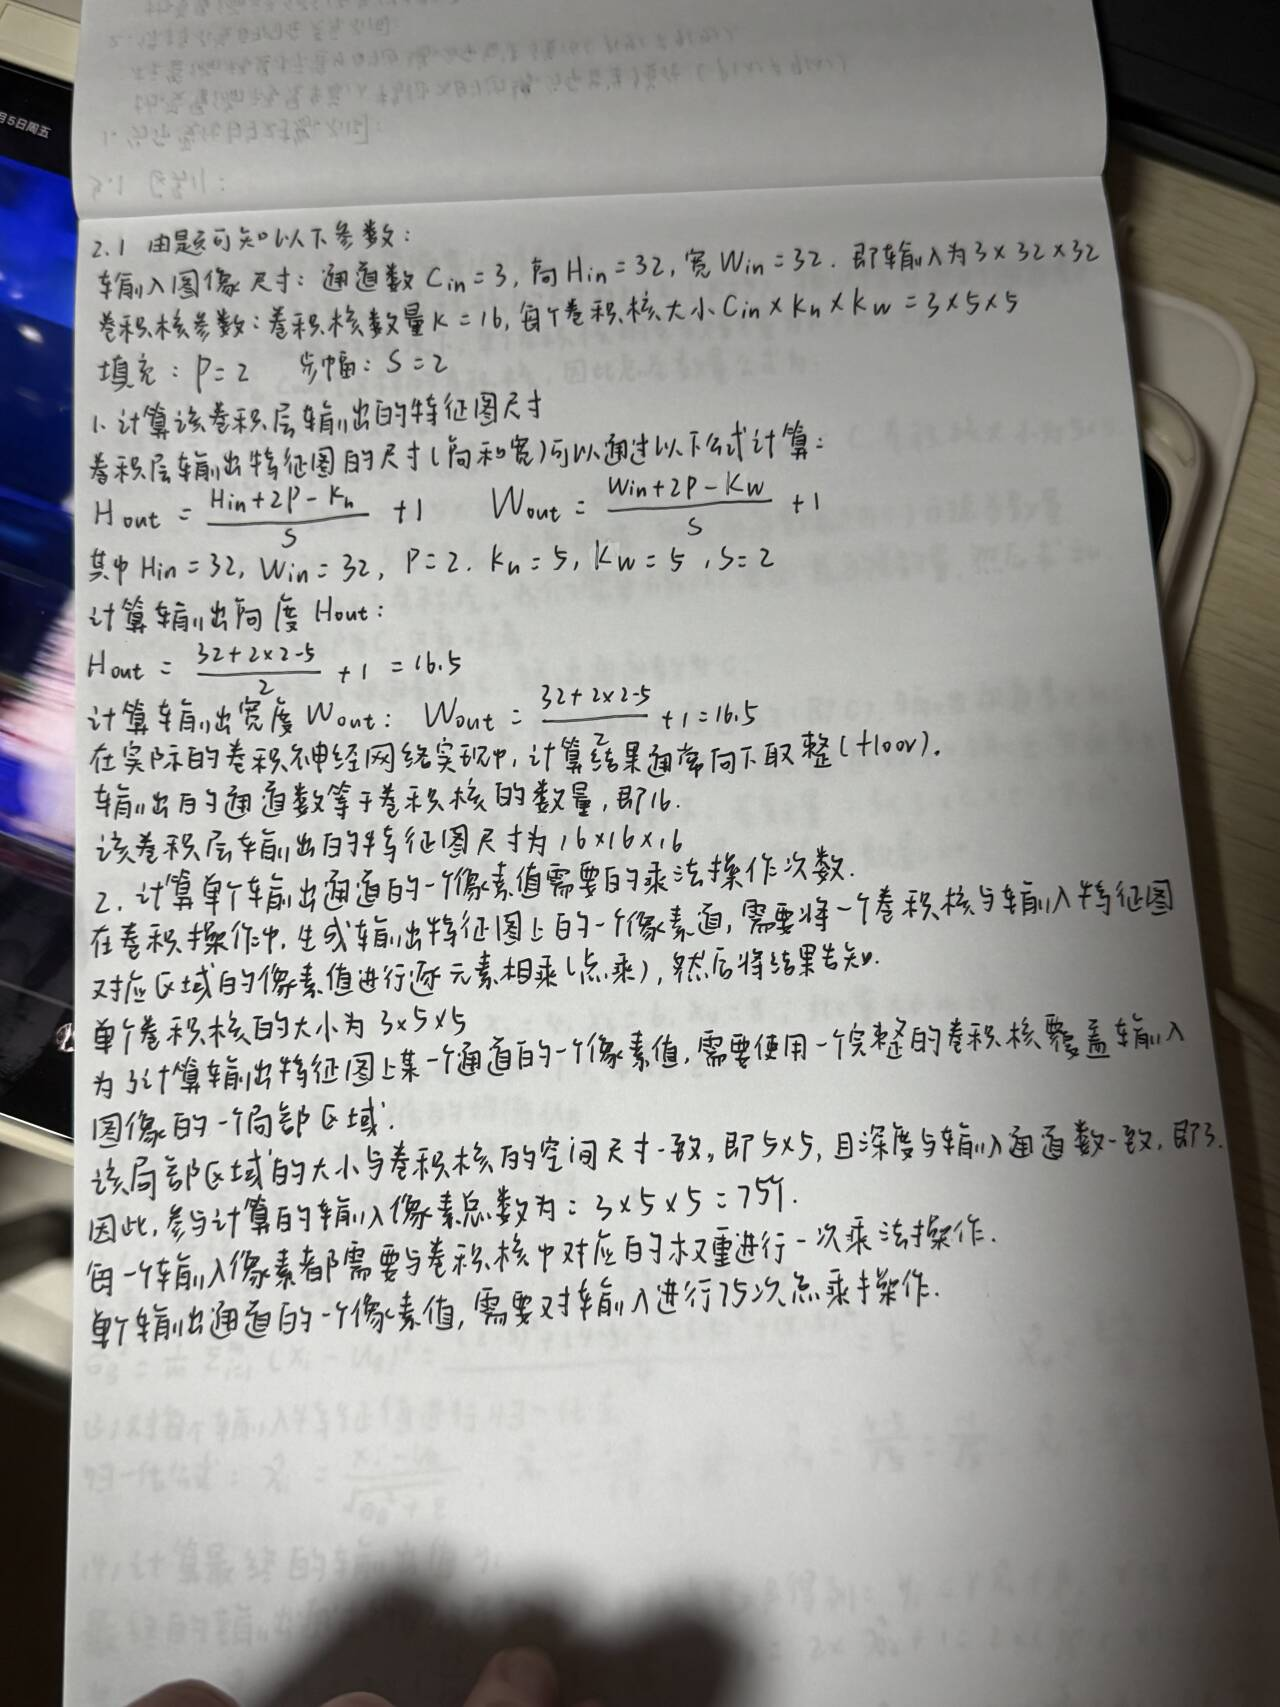

## 2.2 手动实现二维最大池化（Max Pooling）前向传播

In [1]:
import numpy as np

def max_pool2d_forward(x, kernel_size, stride, padding):
    """
    手动实现二维最大池化前向传播

    参数:
        x: 输入张量，形状 (N, C, H, W)  (batch, channel, height, width)
        kernel_size: 池化窗口大小 (int 或 tuple)
        stride: 步幅 (int 或 tuple)
        padding: 填充 (int 或 tuple)

    返回:
        out: 池化后的输出，形状 (N, C, H_out, W_out)
    """
    # 确保参数为 tuple
    if isinstance(kernel_size, int):
        k_h = k_w = kernel_size
    else:
        k_h, k_w = kernel_size

    if isinstance(stride, int):
        s_h = s_w = stride
    else:
        s_h, s_w = stride

    if isinstance(padding, int):
        p_h = p_w = padding
    else:
        p_h, p_w = padding

    N, C, H, W = x.shape

    # 对输入进行填充（零填充）
    x_padded = np.pad(x, ((0, 0), (0, 0), (p_h, p_h), (p_w, p_w)),
                      mode='constant', constant_values=0)

    # 计算输出尺寸
    H_out = (H + 2 * p_h - k_h) // s_h + 1
    W_out = (W + 2 * p_w - k_w) // s_w + 1

    # 初始化输出张量
    out = np.zeros((N, C, H_out, W_out))

    # 滑动窗口计算最大值
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                h_start = i * s_h
                h_end = h_start + k_h
                for j in range(W_out):
                    w_start = j * s_w
                    w_end = w_start + k_w
                    window = x_padded[n, c, h_start:h_end, w_start:w_end]
                    out[n, c, i, j] = np.max(window)

    return out

# 示例
if __name__ == "__main__":
    x = np.random.randn(2, 3, 32, 32)   # batch=2, channels=3, 32x32
    out = max_pool2d_forward(x, kernel_size=2, stride=2, padding=0)
    print("输入形状:", x.shape)
    print("输出形状:", out.shape)   # 应为 (2,3,16,16)

输入形状: (2, 3, 32, 32)
输出形状: (2, 3, 16, 16)


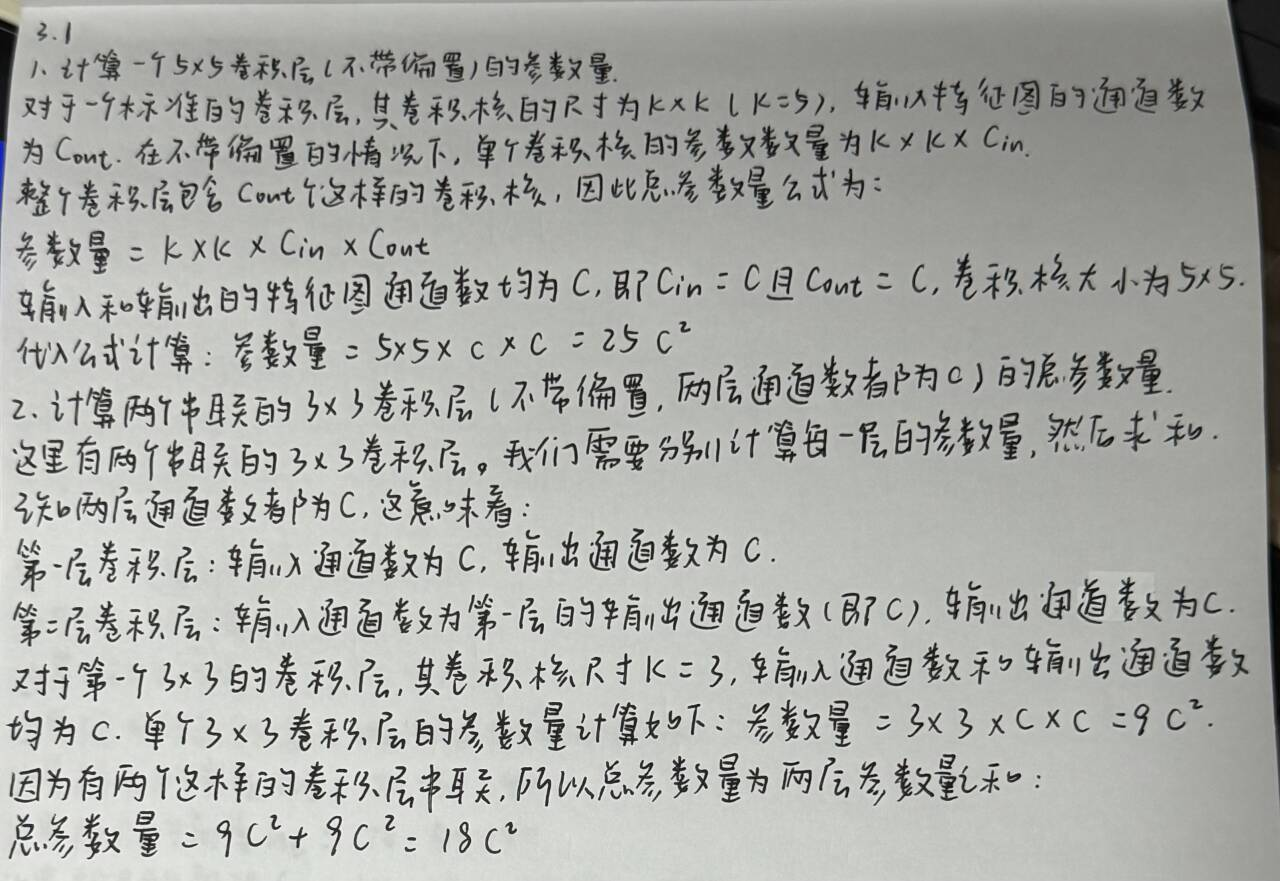

## 3.2 定义 NiN 块（NiN Block）

In [2]:
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    """
    NiN块：一个普通卷积层 + 两个1x1卷积层，每层后跟ReLU激活
    """
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super(NiNBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# 示例
if __name__ == "__main__":
    block = NiNBlock(in_channels=3, out_channels=96,
                     kernel_size=3, stride=1, padding=1)
    x = torch.randn(1, 3, 32, 32)
    out = block(x)
    print("NiN Block 输出形状:", out.shape)   # (1,96,32,32)

NiN Block 输出形状: torch.Size([1, 96, 32, 32])


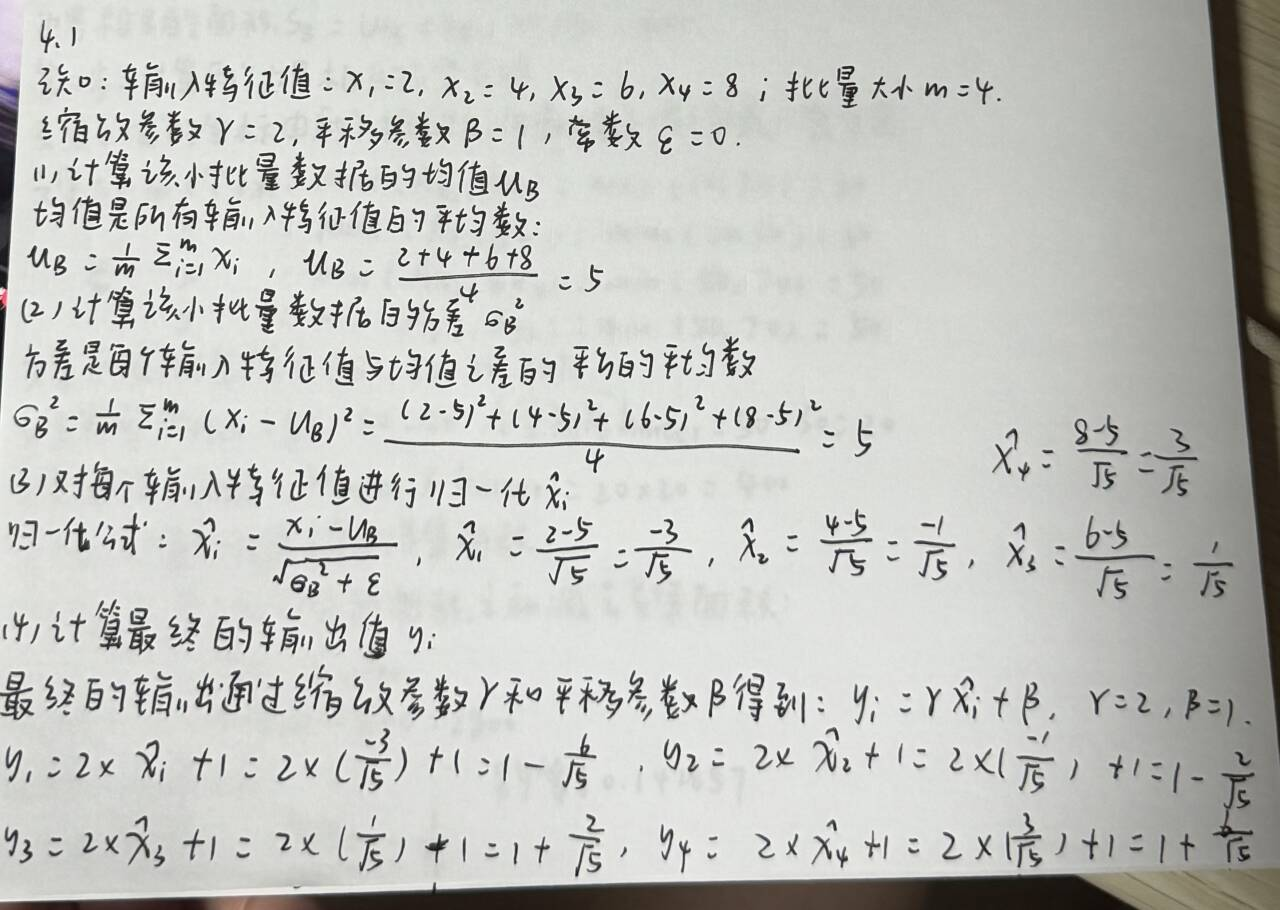

## 4.2 自定义残差块（Residual Block）

In [3]:
import torch
import torch.nn as nn

class Residual(nn.Module):
    """
    残差块：两个3x3卷积层，每个后跟BatchNorm，若use_1x1conv=True则用1x1卷积调整捷径。
    """
    def __init__(self, in_channels, out_channels, use_1x1conv=False, stride=1):
        super(Residual, self).__init__()
        # 第一个卷积层
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 第二个卷积层
        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 如果输入输出通道不同或需要调整尺寸，则使用1x1卷积
        if use_1x1conv:
            self.shortcut = nn.Conv2d(in_channels, out_channels,
                                      kernel_size=1, stride=stride)
        else:
            self.shortcut = None

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.shortcut is not None:
            identity = self.shortcut(x)

        out += identity
        out = self.relu(out)
        return out

# 示例
if __name__ == "__main__":
    # 输入输出通道相同，不调整捷径
    block1 = Residual(64, 64, use_1x1conv=False)
    x1 = torch.randn(1, 64, 32, 32)
    out1 = block1(x1)
    print("残差块1输出形状:", out1.shape)   # (1,64,32,32)

    # 输入输出通道不同，使用1x1卷积调整
    block2 = Residual(32, 64, use_1x1conv=True, stride=2)
    x2 = torch.randn(1, 32, 32, 32)
    out2 = block2(x2)
    print("残差块2输出形状:", out2.shape)   # (1,64,16,16)

残差块1输出形状: torch.Size([1, 64, 32, 32])
残差块2输出形状: torch.Size([1, 64, 16, 16])


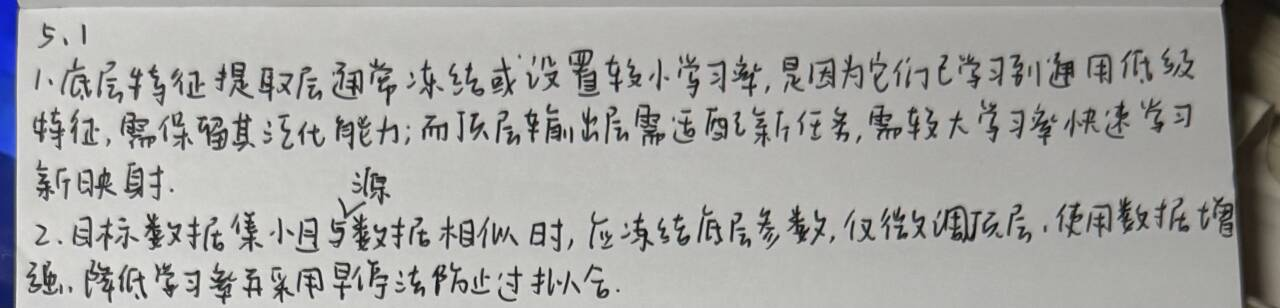

## 5.2 图像增广管道（Image Augmentation Pipeline）

In [4]:
import torchvision.transforms as transforms

# 创建增广管道
augmentation_pipeline = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),   # 随机裁剪并缩放至224x224
    transforms.RandomHorizontalFlip(p=0.5),                 # 50%概率水平翻转
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),  # 颜色扰动
    transforms.ToTensor()                                   # 转换为Tensor
])

# 示例（需要PIL图像）
# from PIL import Image
# img = Image.open('example.jpg')
# tensor_img = augmentation_pipeline(img)
# print(tensor_img.shape)   # (3,224,224)

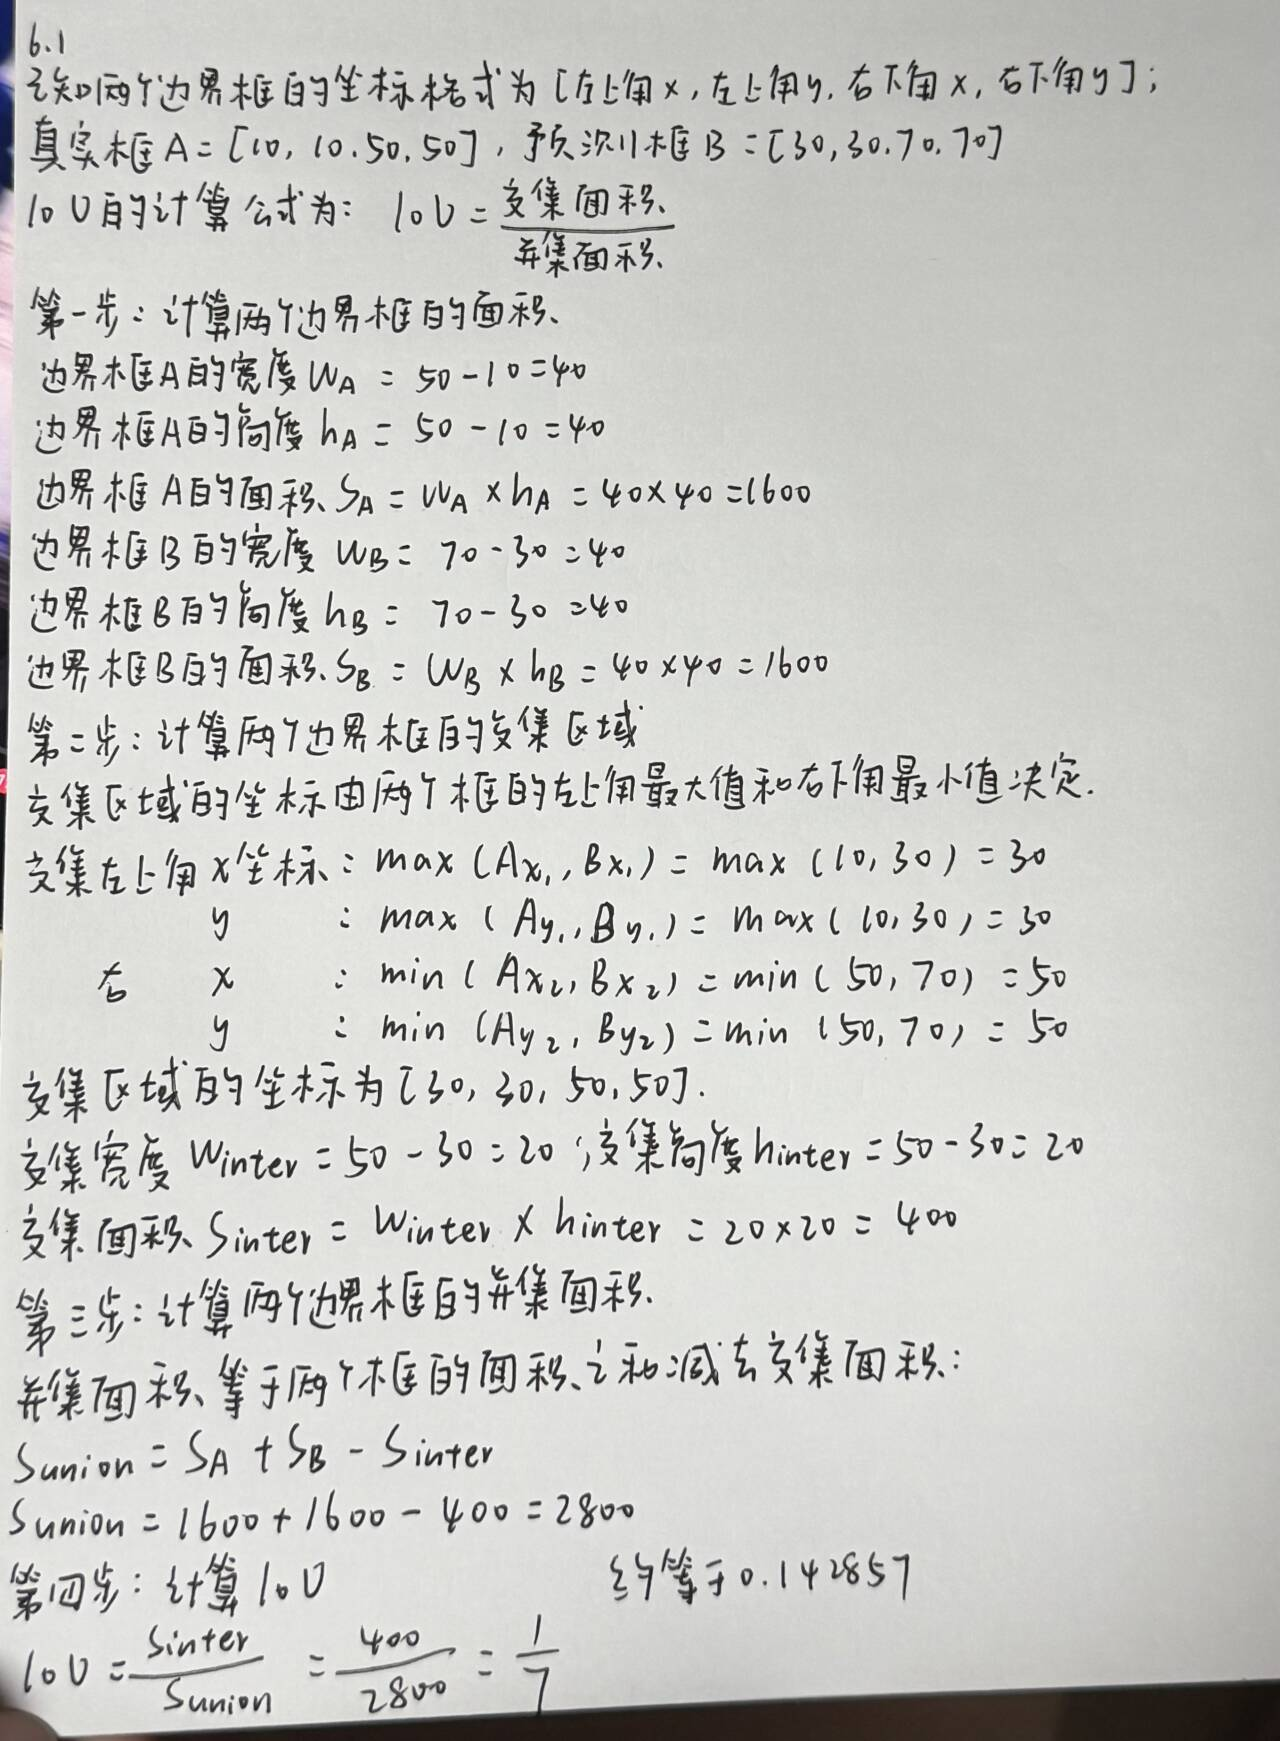

## 6.2 标签平滑后的交叉熵损失函数

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LabelSmoothingCrossEntropy(nn.Module):
    """
    标签平滑交叉熵损失
    参数：
        epsilon: 平滑因子，默认0.1
        reduction: 损失归约方式 ('none','mean','sum')
    """
    def __init__(self, epsilon=0.1, reduction='mean'):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
        self.reduction = reduction

    def forward(self, pred, target):
        """
        pred: 模型输出的logits，形状 (N, C)
        target: 真实标签索引，形状 (N,)
        """
        N, C = pred.shape
        # 构建平滑后的标签分布
        smooth_label = torch.full_like(pred, self.epsilon / (C - 1))
        smooth_label.scatter_(1, target.unsqueeze(1), 1.0 - self.epsilon)

        log_probs = F.log_softmax(pred, dim=1)
        loss = -torch.sum(smooth_label * log_probs, dim=1)   # 逐样本交叉熵

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# 示例
if __name__ == "__main__":
    # 模拟一个三分类问题，batch=2
    logits = torch.tensor([[2.0, 1.0, 0.1],
                           [0.5, 2.5, 1.0]])
    labels = torch.tensor([0, 1])   # 真实类别

    criterion = LabelSmoothingCrossEntropy(epsilon=0.1, reduction='mean')
    loss = criterion(logits, labels)
    print("标签平滑后的交叉熵损失:", loss.item())

标签平滑后的交叉熵损失: 0.5216928720474243
